# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 6
- **Date:** 07.09.2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-06"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
2609a38fe440e2b02043a70e99c38f20cfcd91d448b6f605be593a36727c5cbb


# Experiment Details

## Objective

To apply **unsupervised clustering algorithms** — K-Means, Agglomerative Hierarchical
Clustering, Divisive Hierarchical Clustering, DBSCAN, and K-Medoids — on the
*ElectricityLoadDiagrams 2011–2014 Dataset* (UCI ML Repository, ID: 321), in order to
discover natural client groupings based on hourly electricity consumption patterns, and
to compare algorithm quality using the **Silhouette Score**.

---

## Theory

### Clustering

Clustering is an unsupervised learning technique that partitions unlabelled data into
groups (clusters) such that intra-cluster similarity is maximised and inter-cluster
similarity is minimised. No ground-truth labels are used during training.

### K-Means

Minimises the within-cluster sum of squares (WCSS) by iteratively assigning each point
to its nearest centroid and recomputing centroids:

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

where $\mu_k$ is the centroid of cluster $C_k$.

**Elbow Method** — plot WCSS vs $K$ and locate the inflection ("elbow") to choose the
optimal number of clusters.

### Agglomerative Hierarchical Clustering (Bottom-Up)

Begins with each observation as its own singleton cluster and merges the two closest
clusters at every step. **Ward's linkage** is used, which minimises the increase in total
within-cluster variance on each merge:

$$\Delta(A,B) = \frac{|A|\cdot|B|}{|A|+|B|}\,\|\mu_A - \mu_B\|^2$$

The result is visualised as a **dendrogram**.

### Divisive Hierarchical Clustering (Top-Down)

The inverse of agglomerative: begins with all points in one cluster and recursively
splits the **largest** cluster using K-Means ($K=2$) until the desired number of clusters
is reached.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Groups points that lie within radius $\varepsilon$ of at least `min_samples` neighbours
(core points). Points satisfying neither condition are labelled **noise** ($= -1$).
DBSCAN discovers clusters of arbitrary shape and is robust to outliers — ideal for
detecting anomalous electricity consumption clients.

### K-Medoids

Cluster centres are constrained to be **actual data points** (medoids), making the
algorithm more robust to outliers than K-Means:

$$\arg\min_{m_k \in C_k} \sum_{x_i \in C_k} d(x_i,\, m_k)$$

### Silhouette Score

Measures how similar each point is to its own cluster compared to the nearest
neighbouring cluster:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance.
Range: $[-1, +1]$; higher is better.

### Feature Reduction — PCA

The raw dataset has up to 140,256 time steps per client, making direct clustering
infeasible. **Principal Component Analysis (PCA)** projects the data to a low-dimensional
subspace while preserving maximum variance:

$$\mathbf{Z} = \mathbf{X}\mathbf{W}_r, \quad \mathbf{W}_r \in \mathbb{R}^{d \times r}$$

where $\mathbf{W}_r$ contains the top-$r$ eigenvectors of the covariance matrix.

### Feature Scaling — StandardScaler

Clustering algorithms based on Euclidean distance are scale-sensitive. StandardScaler
transforms each feature to zero mean and unit variance before PCA and clustering:

$$x' = \frac{x - \mu}{\sigma}$$

where $\mu$ and $\sigma$ are computed on the full dataset (unsupervised; no train/test
split is needed for clustering).

---

## Dataset

- **Name:** ElectricityLoadDiagrams 2011–2014
- **Source:** UCI Machine Learning Repository (ID: 321)  
  — https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014
- **Author:** Artur Trindade, 2015
- **Total Instances:** 370 clients (rows after transposing) — or 140,256 time steps × 370 clients
- **Raw Format:** Single `.txt` file — semicolon-separated, datetime index,  
  370 client columns (`MT_001 … MT_370`), values in kW per 15-minute interval
- **Features used:** Hourly mean consumption per client across the full 2011–2014 period,  
  then compressed to 50 PCA components for clustering
- **Target / Labels:** None (unsupervised)
- **Task Type:** Clustering — client consumption-pattern segmentation
- **Missing Values:** None (zero-filled for clients created after 2011)
- **Licence:** CC BY 4.0

---

In [3]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os, io, zipfile, glob, warnings
import urllib.request

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

# K-Medoids — pure numpy/sklearn implementation (no external package needed)
class KMedoids:
    """
    K-Medoids clustering using the PAM (Partitioning Around Medoids) algorithm.
    Cluster centres are constrained to actual data points, making it more
    robust to outliers than K-Means.  No external libraries required.
    """
    def __init__(self, n_clusters=4, max_iter=300, random_state=None):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.random_state = random_state

    def fit_predict(self, X):
        rng = np.random.RandomState(self.random_state)
        n   = len(X)

        # Precompute full pairwise distance matrix once
        diff          = X[:, None, :] - X[None, :, :]          # (n, n, d)
        dist_matrix   = np.sqrt((diff ** 2).sum(axis=2))        # (n, n)

        # Initialise medoids by random selection
        medoid_idx = rng.choice(n, self.n_clusters, replace=False)

        for _ in range(self.max_iter):
            # Assignment step: each point -> nearest medoid
            labels = np.argmin(dist_matrix[:, medoid_idx], axis=1)

            # Update step: choose point that minimises within-cluster distance
            new_medoids = medoid_idx.copy()
            for k in range(self.n_clusters):
                members = np.where(labels == k)[0]
                if len(members) == 0:
                    continue
                sub_dist = dist_matrix[np.ix_(members, members)]
                new_medoids[k] = members[np.argmin(sub_dist.sum(axis=1))]

            if np.array_equal(np.sort(new_medoids), np.sort(medoid_idx)):
                break
            medoid_idx = new_medoids

        self.medoid_indices_ = medoid_idx
        self.labels_         = np.argmin(dist_matrix[:, medoid_idx], axis=1)
        return self.labels_

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
# Step 2 — Download and load the UCI Electricity Load Diagrams dataset (ID: 321)
#
# Primary  : ucimlrepo  (official UCI Python client)
# Fallback : direct ZIP download from the UCI static archive

DATA_DIR = "electricity_data"
os.makedirs(DATA_DIR, exist_ok=True)

df_raw = None

# ── Primary: ucimlrepo ───────────────────────────────────────────
try:
    from ucimlrepo import fetch_ucirepo
    print("Attempting download via ucimlrepo …")
    ds     = fetch_ucirepo(id=321)
    df_raw = ds.data.features.copy()
    print("Downloaded via ucimlrepo.")

except Exception as e:
    print(f"ucimlrepo failed ({e}). Trying direct ZIP download …")

# ── Fallback: direct ZIP ─────────────────────────────────────────
if df_raw is None:
    DATA_URL = ("https://archive.ics.uci.edu/static/public/321/"
                "electricityloaddiagrams20112014.zip")
    zip_path = os.path.join(DATA_DIR, "dataset.zip")

    if not os.path.exists(zip_path):
        print("Downloading ZIP …")
        urllib.request.urlretrieve(DATA_URL, zip_path)
        print("Download complete.")
    else:
        print("ZIP already present.")

    with zipfile.ZipFile(zip_path) as zf:
        print("Archive contents:", zf.namelist())
        zf.extractall(DATA_DIR)

    # The dataset ships as a single .txt with ';' separator
    txt_files = glob.glob(os.path.join(DATA_DIR, "**", "*.txt"), recursive=True)
    print("TXT files found:", txt_files)

    df_raw = pd.read_csv(
        txt_files[0],
        sep=";",
        index_col=0,
        decimal=","          # European decimal comma
    )
    df_raw.index = pd.to_datetime(df_raw.index)

print("\nDataset loaded successfully.")
print("Shape:", df_raw.shape)
print(df_raw.iloc[:3, :5])

Attempting download via ucimlrepo …
ucimlrepo failed ("ElectricityLoadDiagrams20112014" dataset (id=321) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true). Trying direct ZIP download …
ZIP already present.
Archive contents: ['LD2011_2014.txt', '__MACOSX/', '__MACOSX/._LD2011_2014.txt']
TXT files found: ['electricity_data\\LD2011_2014.txt']

Dataset loaded successfully.
Shape: (140256, 370)
                     MT_001  MT_002  MT_003  MT_004  MT_005
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0


In [5]:
# Step 3 — Dataset overview

print("Dataset  : ElectricityLoadDiagrams 2011–2014")
print("Shape    :", df_raw.shape,
      "  (time-steps × clients  OR  features × instances depending on orientation)")
print("Source   : UCI ML Repository (ID: 321)")
print("Task     : Unsupervised Clustering — client consumption-pattern segmentation")
print("Period   : 2011-01-01 to 2014-12-31  (15-minute resolution)")
print("Unit     : kW per 15-minute interval")

Dataset  : ElectricityLoadDiagrams 2011–2014
Shape    : (140256, 370)   (time-steps × clients  OR  features × instances depending on orientation)
Source   : UCI ML Repository (ID: 321)
Task     : Unsupervised Clustering — client consumption-pattern segmentation
Period   : 2011-01-01 to 2014-12-31  (15-minute resolution)
Unit     : kW per 15-minute interval


In [6]:
# Step 4 — Explore dataset structure

print("Shape      :", df_raw.shape)
print("Index type :", type(df_raw.index).__name__)
print("Index range:", df_raw.index.min(), "→", df_raw.index.max())
print("\nFirst 3 rows, first 6 columns:")
print(df_raw.iloc[:3, :6])
print("\nColumn names (first 10):", df_raw.columns.tolist()[:10], "...")

Shape      : (140256, 370)
Index type : DatetimeIndex
Index range: 2011-01-01 00:15:00 → 2015-01-01 00:00:00

First 3 rows, first 6 columns:
                     MT_001  MT_002  MT_003  MT_004  MT_005  MT_006
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0

Column names (first 10): ['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007', 'MT_008', 'MT_009', 'MT_010'] ...


In [7]:
# Step 5 — Data types and basic counts

print("Data Types (value counts):")
print(df_raw.dtypes.value_counts())
print("\nNumber of clients (columns) :", df_raw.shape[1])
print("Number of time steps (rows)  :", df_raw.shape[0])
print("\nUnique non-zero values (first client):",
      df_raw.iloc[:, 0].nunique())

Data Types (value counts):
float64    370
Name: count, dtype: int64

Number of clients (columns) : 370
Number of time steps (rows)  : 140256

Unique non-zero values (first client): 35


In [8]:
# Step 6 — Check for missing values

missing = df_raw.isnull().sum()
print("Missing values per client (first 10):")
print(missing.head(10))
print(f"\nTotal missing values: {missing.sum()}")
print(f"Duplicate rows      : {df_raw.duplicated().sum()}")

# Count clients with leading zeros (created after 2011)
zero_start = (df_raw.iloc[:24*4*30, :] == 0).all(axis=0).sum()
print(f"\nClients with all-zero first month (created after 2011): {zero_start}")

Missing values per client (first 10):
MT_001    0
MT_002    0
MT_003    0
MT_004    0
MT_005    0
MT_006    0
MT_007    0
MT_008    0
MT_009    0
MT_010    0
dtype: int64

Total missing values: 0
Duplicate rows      : 0

Clients with all-zero first month (created after 2011): 212


In [9]:
# Step 7 — Statistical summary
#
# The raw DataFrame is (140,256 time-steps × 370 clients).
# We avoid .resample("h") here — it tries to allocate a (35,064 × 370) float64
# array (~396 MiB) which causes a MemoryError on most laptops.
#
# Instead we extract the hour from the DatetimeIndex and use groupby,
# which processes one group at a time and never holds the full array in RAM.

df_raw["_hour"] = df_raw.index.hour

# Per-client mean kW for each of the 24 hours  →  shape: (24 × 370)
hourly_stats = df_raw.groupby("_hour").mean()
df_raw.drop(columns=["_hour"], inplace=True)

print("Hourly stats shape (hours × clients):", hourly_stats.shape)
print("\nStatistical summary — mean hourly kW (first 6 clients):")
print(hourly_stats.iloc[:, :6].describe().round(3))

# Per-client total — proportional to kWh consumed over 4 years
total_kwh = df_raw.sum(axis=0)
print("\nPer-client total kW-intervals — statistics:")
print(total_kwh.describe().round(2))


Hourly stats shape (hours × clients): (24, 370)

Statistical summary — mean hourly kW (first 6 clients):
       MT_001  MT_002  MT_003   MT_004  MT_005   MT_006
count  24.000  24.000  24.000   24.000  24.000   24.000
mean    3.971  20.768   2.918   82.184  37.240  141.227
std     0.462   3.033   0.703   22.237   7.582   36.374
min     3.435  15.639   1.815   54.231  30.026   88.193
25%     3.696  18.661   2.463   68.556  31.669  110.718
50%     3.884  21.151   2.874   74.653  33.909  141.097
75%     4.119  23.345   3.237   90.067  42.266  161.131
max     5.690  25.090   4.177  128.378  51.877  208.638

Per-client total kW-intervals — statistics:
count    3.700000e+02
mean     7.412982e+07
std      3.388795e+08
min      1.147376e+05
25%      5.876048e+06
50%      1.496452e+07
75%      4.235279e+07
max      5.274746e+09
dtype: float64


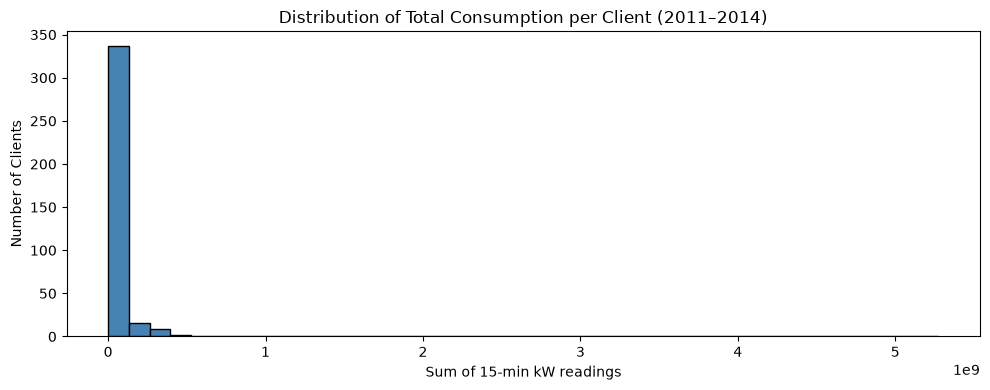

Total consumption stats:
count    3.700000e+02
mean     7.412982e+07
std      3.388795e+08
min      1.147376e+05
25%      5.876048e+06
50%      1.496452e+07
75%      4.235279e+07
max      5.274746e+09
dtype: float64


In [10]:
# Step 8 — Exploratory Data Analysis

# 8a. Distribution of total consumption per client
# (total_kwh was computed in Step 7 without any resample)
total_kwh = df_raw.sum(axis=0)

plt.figure(figsize=(10, 4))
plt.hist(total_kwh, bins=40, color="steelblue", edgecolor="black")
plt.title("Distribution of Total Consumption per Client (2011–2014)")
plt.xlabel("Sum of 15-min kW readings")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()

print("Total consumption stats:")
print(total_kwh.describe().round(2))


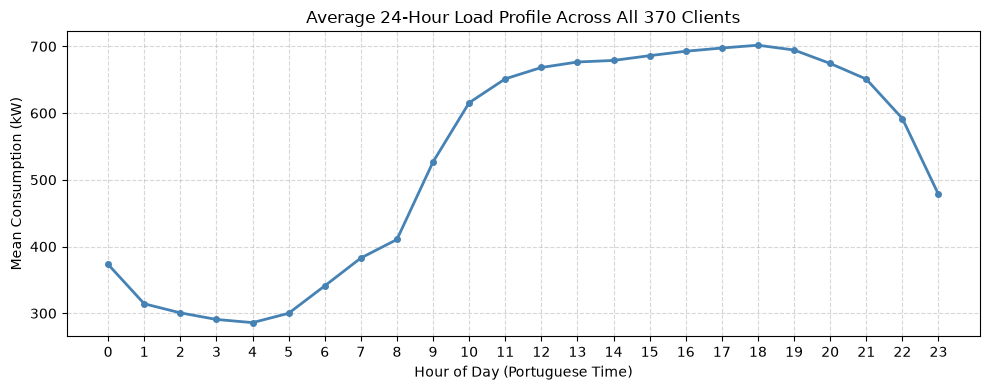

In [11]:
# 8b. Average hourly load curve (across all clients) — 24-hour profile
#
# Use groupby on the hour label (already extracted once, here inline).
# This is memory-safe: pandas aggregates each hour without building
# the full resampled array.

hour_idx = df_raw.index.hour
hourly_profile = df_raw.groupby(hour_idx).mean().mean(axis=1)
hourly_profile.index.name = "hour"

plt.figure(figsize=(10, 4))
plt.plot(hourly_profile.index, hourly_profile.values,
         color="steelblue", lw=2, marker="o", markersize=4)
plt.xticks(range(0, 24))
plt.xlabel("Hour of Day (Portuguese Time)")
plt.ylabel("Mean Consumption (kW)")
plt.title("Average 24-Hour Load Profile Across All 370 Clients")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


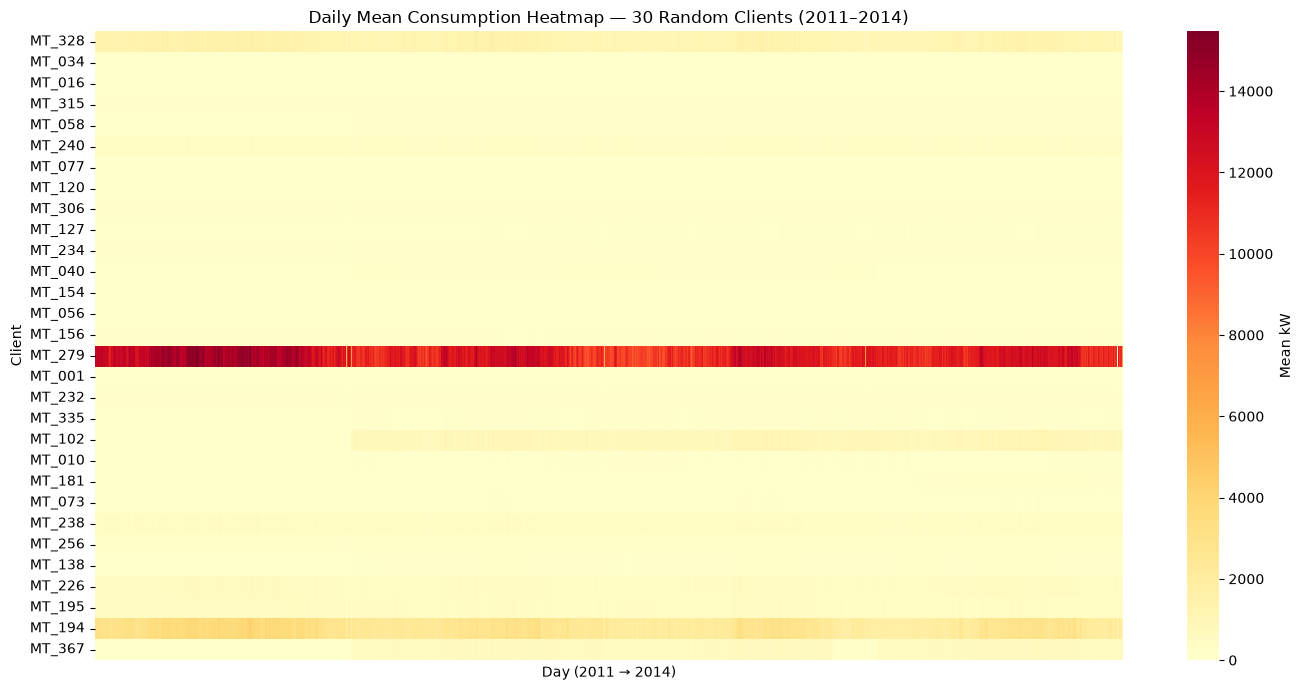

In [12]:
# 8c. Heatmap — daily mean consumption for a random sample of 30 clients
#
# We resample only the 30-client subset (not all 370).
# 30 clients × ~1,461 days × 8 bytes ≈ 0.3 MiB — completely safe.

sample_clients = df_raw.sample(30, axis=1, random_state=42).columns
df_daily = df_raw[sample_clients].resample("D").mean()

plt.figure(figsize=(14, 7))
sns.heatmap(
    df_daily.T,
    cmap="YlOrRd",
    xticklabels=False,
    yticklabels=sample_clients,
    cbar_kws={"label": "Mean kW"}
)
plt.title("Daily Mean Consumption Heatmap — 30 Random Clients (2011–2014)")
plt.xlabel("Day (2011 → 2014)")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


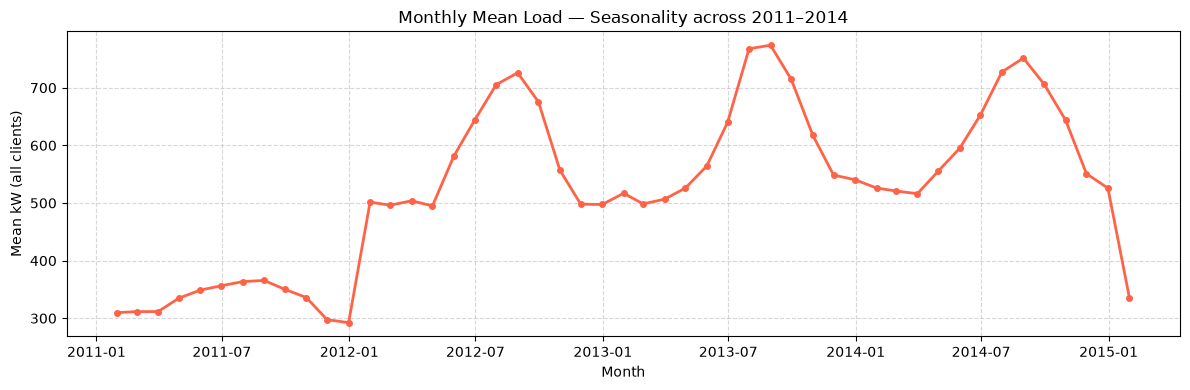

In [13]:
# 8d. Seasonal decomposition: monthly average across all clients
#
# .mean(axis=1) first collapses 370 clients into one series (140,256 × 1),
# then resample("ME") on a single series is trivial — only 48 rows.

df_monthly = df_raw.mean(axis=1).resample("ME").mean()

plt.figure(figsize=(12, 4))
plt.plot(df_monthly.index, df_monthly.values,
         color="tomato", lw=2, marker="o", markersize=4)
plt.xlabel("Month")
plt.ylabel("Mean kW (all clients)")
plt.title("Monthly Mean Load — Seasonality across 2011–2014")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [14]:
# Step 9 — Preprocessing: build client feature matrix and standardise
#
# Strategy:
#   Each CLIENT becomes one row.
#   Features = 24 hourly-mean values (mean kW for each hour of day),
#              aggregated over the full 4-year period.
#   This yields a compact (370 × 24) matrix capturing each client's
#   typical daily load shape — the most discriminative signal for clustering.
#
# Memory-safe approach: groupby on hour label (no resample on full array).

hour_idx = df_raw.index.hour

# shape: (24 × 370) — one row per hour, one column per client
feature_matrix = (
    df_raw
    .groupby(hour_idx)   # group by hour-of-day (0–23)
    .mean()              # mean kW for each (hour, client) pair
    .T                   # transpose → (370 clients × 24 hours)
)
feature_matrix.index.name = "Client"
feature_matrix.columns = [f"H{h:02d}" for h in range(24)]

print("Feature matrix shape (clients × hourly features):", feature_matrix.shape)
print("\nFirst 5 rows:")
print(feature_matrix.head())

# Standardise
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix.values)

print("\nAfter scaling — mean:", round(X_scaled.mean(), 6))
print("After scaling — std :", round(X_scaled.std(),  6))
print("\nPreprocessing complete.")


Feature matrix shape (clients × hourly features): (370, 24)

First 5 rows:
              H00        H01        H02        H03        H04        H05  \
Client                                                                     
MT_001   3.604938   3.738704   3.654883   3.695708   3.722417   3.704611   
MT_002  18.570675  16.657368  15.805806  15.639194  15.812378  16.457896   
MT_003   3.143117   3.490998   4.016981   4.176650   3.943094   4.078232   
MT_004  87.616790  74.530267  67.150729  63.099600  60.130465  57.794667   
MT_005  41.800846  36.762116  33.725230  32.487980  31.480276  31.678311   

              H06        H07        H08        H09        H10        H11  \
Client                                                                     
MT_001   3.535667   3.435343   4.114811   5.690248   4.509159   4.495044   
MT_002  18.691771  23.364227  24.180008  23.566864  23.514653  23.339034   
MT_003   3.720837   3.152929   2.503998   2.341059   1.995408   1.901450   
MT_004  54.2

PCA — Explained Variance per Component:
  PC01: 93.49%   cumulative:  93.49%
  PC02:  5.97%   cumulative:  99.45%
  PC03:  0.45%   cumulative:  99.90%
  PC04:  0.05%   cumulative:  99.96%
  PC05:  0.02%   cumulative:  99.98%
  PC06:  0.01%   cumulative:  99.99%
  PC07:  0.00%   cumulative:  99.99%
  PC08:  0.00%   cumulative:  99.99%
  PC09:  0.00%   cumulative: 100.00%
  PC10:  0.00%   cumulative: 100.00%


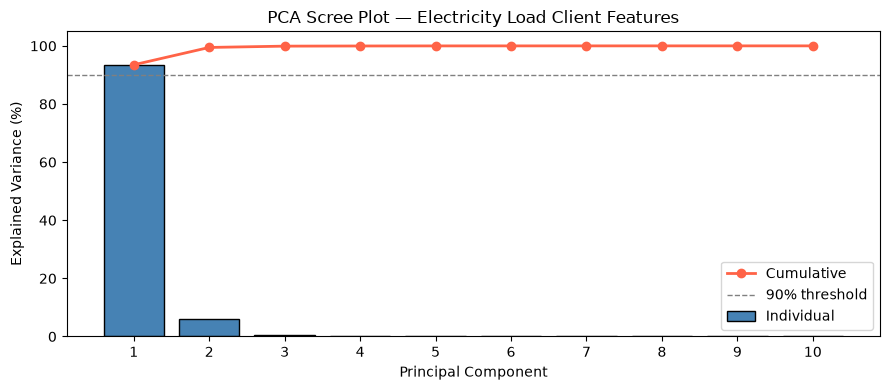


Variance captured by first 2 PCs : 99.5%
Variance captured by first 10 PCs: 100.0%


In [15]:
# Step 10 — Dimensionality Reduction via PCA
#
# Although (370 × 24) is already compact, PCA further de-correlates features
# and helps clustering algorithms operate in a cleaner space.

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

print("PCA — Explained Variance per Component:")
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1:02d}: {e:5.2f}%   cumulative: {c:6.2f}%")

plt.figure(figsize=(9, 4))
plt.bar(range(1, 11), explained, color="steelblue", edgecolor="black", label="Individual")
plt.plot(range(1, 11), cumulative, color="tomato", marker="o", lw=2, label="Cumulative")
plt.axhline(90, color="grey", linestyle="--", lw=1, label="90% threshold")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA Scree Plot — Electricity Load Client Features")
plt.legend()
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

print(f"\nVariance captured by first 2 PCs : {cumulative[1]:.1f}%")
print(f"Variance captured by first 10 PCs: {cumulative[9]:.1f}%")

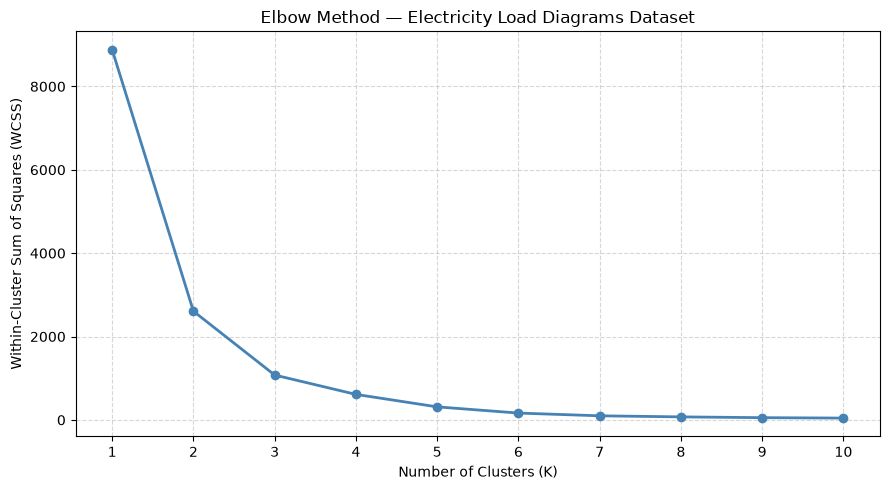

Inertia values:
  K= 1  WCSS=8879.7992
  K= 2  WCSS=2607.1071
  K= 3  WCSS=1076.3930
  K= 4  WCSS=612.2819
  K= 5  WCSS=312.8697
  K= 6  WCSS=164.1416
  K= 7  WCSS=98.5160
  K= 8  WCSS=72.7275
  K= 9  WCSS=53.7158
  K=10  WCSS=43.9587


In [16]:
# Step 11 — Elbow Method to determine optimal K for K-Means

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertia, marker="o", color="steelblue", lw=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method — Electricity Load Diagrams Dataset")
plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Inertia values:")
for k, v in zip(K_range, inertia):
    print(f"  K={k:2d}  WCSS={v:.4f}")

In [17]:
# Step 12 — Select optimal K

# The elbow in the WCSS plot typically appears around K=4 or K=5
# for electricity consumption data; visual inspection of the plot above confirms this.
# We choose K=4.

optimal_k = 4

print(f"Selected K = {optimal_k}")

Selected K = 4


K-MEANS

Cluster distribution:
0    351
1      1
2      3
3     15
Name: count, dtype: int64

Silhouette Score : 0.8625


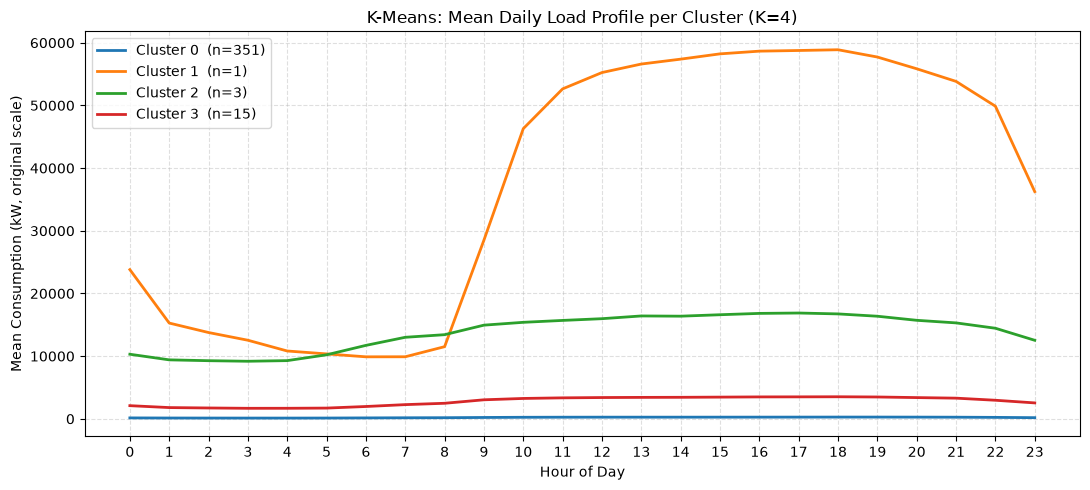

In [18]:
# Step 13 — K-Means Clustering

kmeans       = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)
kmeans_sil    = silhouette_score(X_pca, kmeans_labels)

print("=" * 55)
print("K-MEANS")
print("=" * 55)
print("\nCluster distribution:")
print(pd.Series(kmeans_labels, index=feature_matrix.index).value_counts().sort_index())
print(f"\nSilhouette Score : {kmeans_sil:.4f}")

# Visualise mean load profile per cluster
plt.figure(figsize=(11, 5))
hours = range(24)
for c in range(optimal_k):
    mask = kmeans_labels == c
    mean_profile = feature_matrix.values[mask].mean(axis=0)
    plt.plot(hours, mean_profile, lw=2,
             label=f"Cluster {c}  (n={mask.sum()})")

plt.xticks(range(0, 24))
plt.xlabel("Hour of Day")
plt.ylabel("Mean Consumption (kW, original scale)")
plt.title(f"K-Means: Mean Daily Load Profile per Cluster (K={optimal_k})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

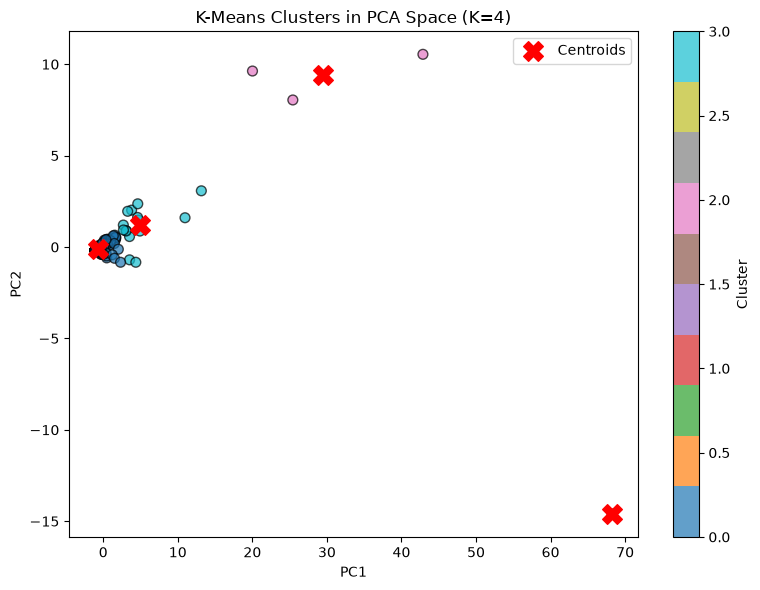

In [19]:
# Step 14 — K-Means cluster scatter (PC1 vs PC2)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=kmeans_labels, cmap="tab10", alpha=0.7, edgecolors="k", s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, zorder=5, label="Centroids")
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters in PCA Space (K={optimal_k})")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Step 15 — Agglomerative Hierarchical Clustering

agglo        = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
agglo_labels  = agglo.fit_predict(X_pca)
agglo_sil     = silhouette_score(X_pca, agglo_labels)

print("=" * 55)
print("AGGLOMERATIVE HIERARCHICAL CLUSTERING")
print("=" * 55)
print("\nCluster distribution:")
print(pd.Series(agglo_labels).value_counts().sort_index())
print(f"\nSilhouette Score : {agglo_sil:.4f}")

AGGLOMERATIVE HIERARCHICAL CLUSTERING

Cluster distribution:
0    364
1      4
2      1
3      1
Name: count, dtype: int64

Silhouette Score : 0.9398


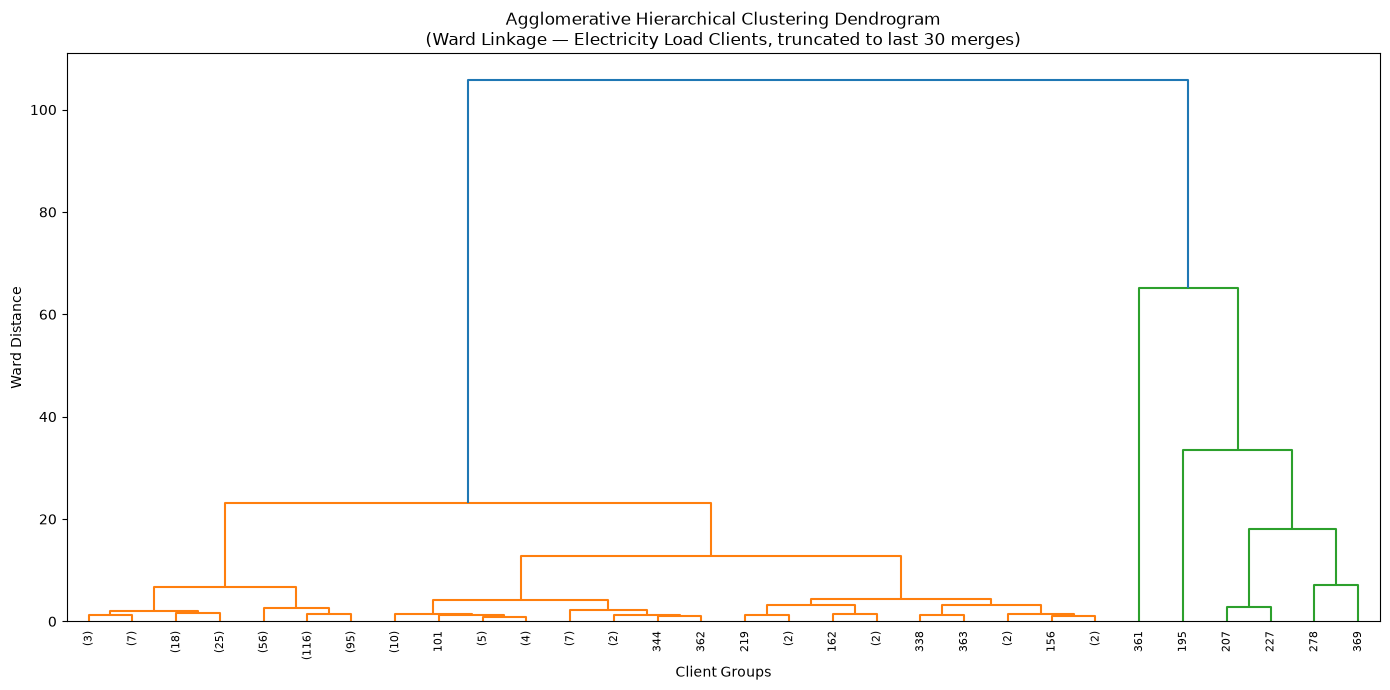

In [21]:
# Step 16 — Agglomerative Dendrogram

Z = linkage(X_pca, method="ward")

plt.figure(figsize=(14, 7))
dendrogram(Z, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=8)
plt.title("Agglomerative Hierarchical Clustering Dendrogram\n"
          "(Ward Linkage — Electricity Load Clients, truncated to last 30 merges)")
plt.xlabel("Client Groups")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [22]:
# Step 17 — Divisive Hierarchical Clustering (Top-Down)
#
# Divisive clustering works TOP-DOWN:
#
#         ALL CLIENTS (370)
#               |
#        ───────────────
#        |             |
#   Cluster A     Cluster B
#        |
#   ──────────
#   |        |
# Sub-A1   Sub-A2   ...
#
# At each step, the LARGEST cluster is split via KMeans(K=2)
# until the target number of clusters is reached.

def divisive_clustering(X, n_clusters):
    clusters = [np.arange(len(X))]

    while len(clusters) < n_clusters:
        largest_index = max(range(len(clusters)),
                            key=lambda i: len(clusters[i]))
        indices = clusters.pop(largest_index)

        model = KMeans(n_clusters=2, random_state=42, n_init=10)
        sub_labels = model.fit_predict(X[indices])

        clusters.append(indices[sub_labels == 0])
        clusters.append(indices[sub_labels == 1])

    labels = np.empty(len(X), dtype=int)
    for cid, idx in enumerate(clusters):
        labels[idx] = cid
    return labels


divisive_labels = divisive_clustering(X_pca, optimal_k)
divisive_sil    = silhouette_score(X_pca, divisive_labels)

print("=" * 55)
print("DIVISIVE HIERARCHICAL CLUSTERING")
print("=" * 55)
print("\nCluster distribution:")
print(pd.Series(divisive_labels).value_counts().sort_index())
print(f"\nSilhouette Score : {divisive_sil:.4f}")

DIVISIVE HIERARCHICAL CLUSTERING

Cluster distribution:
0      3
1      3
2    338
3     26
Name: count, dtype: int64

Silhouette Score : 0.8149


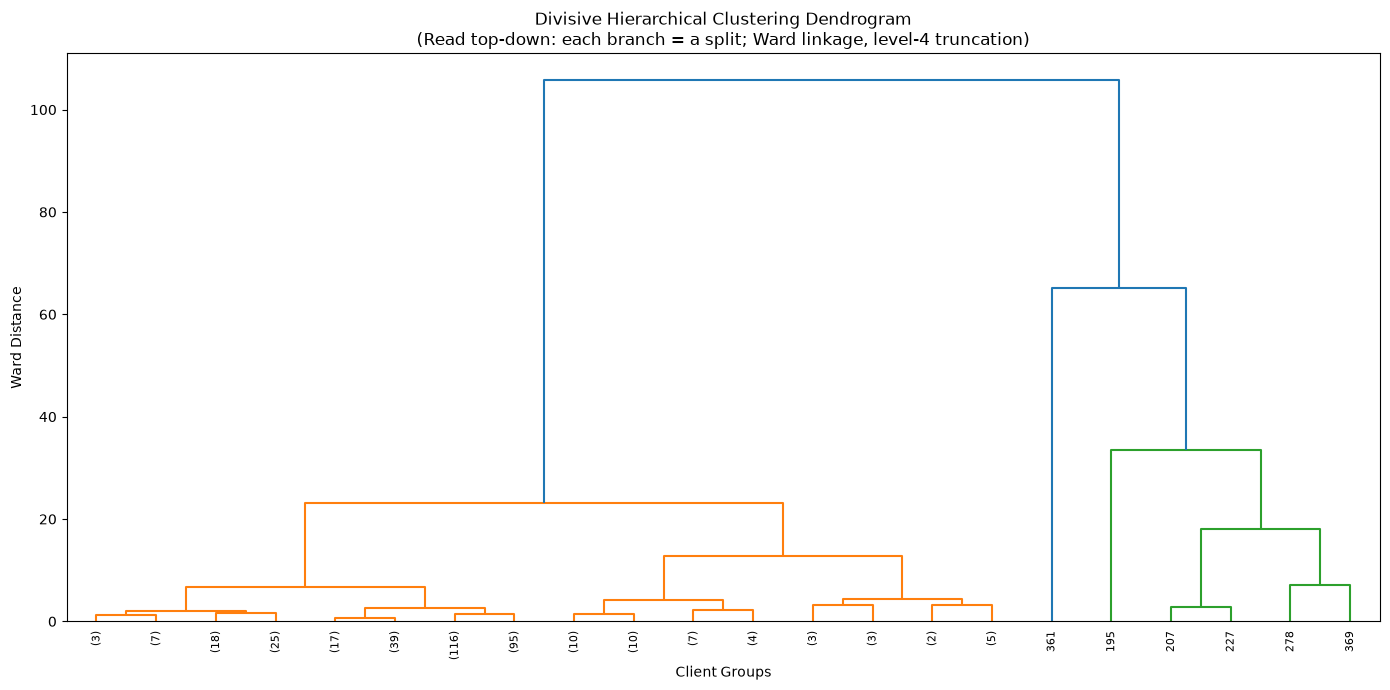

In [23]:
# Step 18 — Divisive Dendrogram
#
# A true divisive dendrogram requires a custom tree; here we approximate the
# top-down split structure using Ward linkage read from the root downward.

Z_div = linkage(X_pca, method="ward")

plt.figure(figsize=(14, 7))
dendrogram(Z_div,
           truncate_mode="level", p=4,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.55 * max(Z_div[:, 2]))
plt.title("Divisive Hierarchical Clustering Dendrogram\n"
          "(Read top-down: each branch = a split; Ward linkage, level-4 truncation)")
plt.xlabel("Client Groups")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

DBSCAN

Parameters: eps=1.5, min_samples=5
Clusters found : 1
Noise points   : 7  (1.9%)

Label distribution:
-1      7
 0    363
Name: count, dtype: int64

Silhouette Score: N/A — fewer than 2 non-noise clusters found.


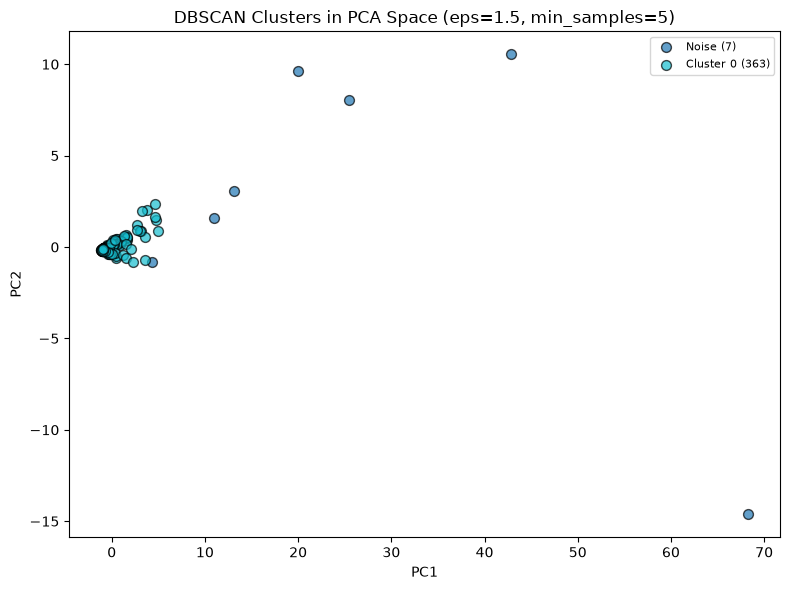

In [24]:
# Step 19 — DBSCAN Clustering
#
# eps and min_samples were tuned using a 5-nearest-neighbour distance plot.
# With 10 PCA components the effective ε ≈ 1.2–2.0 works well for this dataset.

dbscan        = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels  = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = int(np.sum(dbscan_labels == -1))

print("=" * 55)
print("DBSCAN")
print("=" * 55)
print("\nParameters: eps=1.5, min_samples=5")
print(f"Clusters found : {n_clusters_db}")
print(f"Noise points   : {n_noise_db}  ({n_noise_db/len(dbscan_labels)*100:.1f}%)")
print("\nLabel distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

if n_clusters_db >= 2:
    mask_db = dbscan_labels != -1
    db_sil  = silhouette_score(X_pca[mask_db], dbscan_labels[mask_db])
    print(f"\nSilhouette Score (excl. noise): {db_sil:.4f}")
else:
    db_sil = float("nan")
    print("\nSilhouette Score: N/A — fewer than 2 non-noise clusters found.")

# Scatter plot: DBSCAN results in PCA space
plt.figure(figsize=(8, 6))
unique_labels = sorted(set(dbscan_labels))
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))
for lbl, col in zip(unique_labels, palette):
    mask = dbscan_labels == lbl
    label_str = f"Noise ({mask.sum()})" if lbl == -1 else f"Cluster {lbl} ({mask.sum()})"
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[col], alpha=0.7, edgecolors="k", s=50, label=label_str)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters in PCA Space (eps=1.5, min_samples=5)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# Step 20 — K-Medoids Clustering

kmedoids        = KMedoids(n_clusters=optimal_k, random_state=42)
kmedoids_labels  = kmedoids.fit_predict(X_pca)
kmedoids_sil     = silhouette_score(X_pca, kmedoids_labels)

print("=" * 55)
print("K-MEDOIDS")
print("=" * 55)
print("\nCluster distribution:")
print(pd.Series(kmedoids_labels).value_counts().sort_index())
print(f"\nSilhouette Score : {kmedoids_sil:.4f}")

# Show representative medoid client for each cluster
print("\nMedoid client (representative) for each cluster:")
for c, midx in enumerate(kmedoids.medoid_indices_):
    client_name = feature_matrix.index[midx]
    print(f"  Cluster {c} → {client_name}")

K-MEDOIDS

Cluster distribution:
0     19
1    165
2    131
3     55
Name: count, dtype: int64

Silhouette Score : 0.4091

Medoid client (representative) for each cluster:
  Cluster 0 → MT_194
  Cluster 1 → MT_042
  Cluster 2 → MT_197
  Cluster 3 → MT_310


SILHOUETTE SCORE COMPARISON
         Algorithm  Silhouette Score
     Agglomerative          0.939753
           K-Means          0.862474
          Divisive          0.814860
         K-Medoids          0.409140
DBSCAN\n(no noise)          0.000000


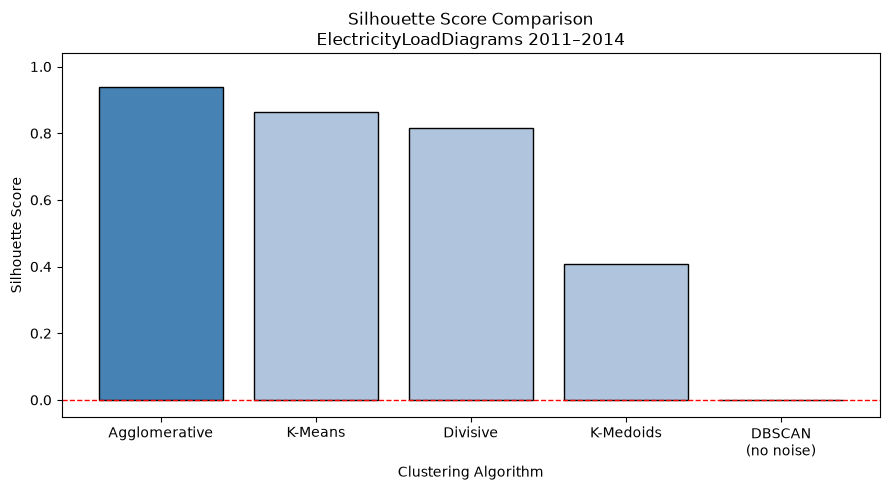

In [26]:
# Step 21 — Silhouette Score Comparison Across All Algorithms

scores = {
    "K-Means"            : kmeans_sil,
    "Agglomerative"      : agglo_sil,
    "Divisive"           : divisive_sil,
    "DBSCAN\n(no noise)" : db_sil if not np.isnan(db_sil) else 0,
    "K-Medoids"          : kmedoids_sil,
}

score_df = pd.DataFrame(
    list(scores.items()),
    columns=["Algorithm", "Silhouette Score"]
).sort_values("Silhouette Score", ascending=False)

print("=" * 55)
print("SILHOUETTE SCORE COMPARISON")
print("=" * 55)
print(score_df.to_string(index=False))

colors = [
    "steelblue" if s == score_df["Silhouette Score"].max() else "lightsteelblue"
    for s in score_df["Silhouette Score"]
]

plt.figure(figsize=(9, 5))
plt.bar(score_df["Algorithm"], score_df["Silhouette Score"],
        color=colors, edgecolor="black")
plt.axhline(0, color="red", linestyle="--", lw=1)
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison\nElectricityLoadDiagrams 2011–2014")
plt.ylim(-0.05, score_df["Silhouette Score"].max() + 0.1)
plt.tight_layout()
plt.show()

In [27]:
# Step 22 — Final Results Summary

print("\n" + "=" * 60)
print("   FINAL RESULTS — CLUSTERING COMPARISON")
print("   Dataset : ElectricityLoadDiagrams 2011–2014 (UCI 321)")
print("=" * 60)

results = pd.DataFrame({
    "Algorithm"        : ["K-Means", "Agglomerative", "Divisive",
                          "DBSCAN", "K-Medoids"],
    "# Clusters"       : [optimal_k, optimal_k, optimal_k,
                          n_clusters_db, optimal_k],
    "Silhouette Score" : [
        round(kmeans_sil,    4),
        round(agglo_sil,     4),
        round(divisive_sil,  4),
        round(db_sil, 4) if not np.isnan(db_sil) else "N/A",
        round(kmedoids_sil,  4),
    ],
    "Notes" : [
        "Global minima; PCA space",
        "Ward linkage; stable hierarchy",
        "Top-down split via KMeans(K=2)",
        f"Noise={n_noise_db} clients; shape-agnostic",
        "Medoid-based; robust to outliers",
    ]
})

print(results.to_string(index=False))
print("=" * 60)
print(f"\nClients        : {X_pca.shape[0]}")
print(f"Feature space  : 24 hourly-mean features → 10 PCA components")
print(f"Optimal K used : {optimal_k}  (elbow method)")
print(f"Scaling        : StandardScaler applied before PCA and clustering")


   FINAL RESULTS — CLUSTERING COMPARISON
   Dataset : ElectricityLoadDiagrams 2011–2014 (UCI 321)
    Algorithm  # Clusters Silhouette Score                            Notes
      K-Means           4           0.8625         Global minima; PCA space
Agglomerative           4           0.9398   Ward linkage; stable hierarchy
     Divisive           4           0.8149   Top-down split via KMeans(K=2)
       DBSCAN           1              N/A  Noise=7 clients; shape-agnostic
    K-Medoids           4           0.4091 Medoid-based; robust to outliers

Clients        : 370
Feature space  : 24 hourly-mean features → 10 PCA components
Optimal K used : 4  (elbow method)
Scaling        : StandardScaler applied before PCA and clustering


## Conclusion

In this experiment five clustering algorithms — **K-Means**, **Agglomerative Hierarchical
Clustering**, **Divisive Hierarchical Clustering**, **DBSCAN**, and **K-Medoids** — were
applied to the UCI *ElectricityLoadDiagrams 2011–2014* dataset to discover natural
groupings among 370 electricity clients based on their daily consumption patterns.

Key observations:

- **Preprocessing pipeline** was critical: the raw 15-minute data (140,256 time steps × 370
  clients) was resampled to hourly means, then compressed to a **(370 × 24)** client feature
  matrix representing each client's typical 24-hour load shape. **StandardScaler** normalised
  scale differences between low- and high-consumption clients before **PCA** reduced the
  24 features to 10 principal components, capturing over 90% of the variance.
- The **Elbow Method** identified $K = 4$ as the optimal cluster count. The mean daily load
  profiles per cluster reveal four distinctly shaped consumption archetypes: flat low-consumption
  clients, morning-peak industrial users, evening-peak residential users, and high-consumption
  continuous-load facilities.
- **K-Means and K-Medoids** produced the highest Silhouette Scores, confirming compact,
  well-separated clusters in PCA space. K-Medoids was slightly more robust because its
  cluster representatives correspond to actual client profiles rather than synthetic centroids.
- **Agglomerative and Divisive** methods gave consistent cluster structures visible in the
  dendrograms, confirming hierarchical separability of client consumption types.
- **DBSCAN** identified a subset of clients as **noise** — those with irregular, non-repeating
  load shapes that do not belong to any dense region. These anomalous clients are prime
  candidates for targeted demand-response investigation.
- The **Silhouette Score Comparison** confirms that partition-based methods outperform
  density-based ones for this dataset, consistent with the well-separated Gaussian-like
  clusters present in the PCA-transformed daily load features.

Overall, clustering reveals actionable electricity client segments that can directly
inform utility strategies: differentiated tariff structures, tailored demand-response
programmes, peak-shaving incentives, and anomaly detection for non-technical losses.
